# Jigsaw Toxic Comment Classification — EDA

**Dataset**: ~160k Wikipedia comments labeled by human raters across 6 toxicity categories.  
**Labels**: `toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, `identity_hate` (multi-label, not mutually exclusive).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import re
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')
test_labels = pd.read_csv('../data/test_labels.csv')

print('Train shape:', train.shape)
print('Test  shape:', test.shape)
print('Test labels shape:', test_labels.shape)
train.head(3)

Train shape: (159571, 8)
Test  shape: (153164, 2)
Test labels shape: (153164, 7)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


## 1. Dataset Overview

In [18]:
print('=== Train dtypes ===')
print(train.dtypes)
print('\n=== Missing values ===')
print(train.isnull().sum())
print('\n=== Sample comment ===')
print(train.loc[train['toxic'] == 1, 'comment_text'].iloc[0])

=== Train dtypes ===
id                object
comment_text      object
toxic              int64
severe_toxic       int64
obscene            int64
threat             int64
insult             int64
identity_hate      int64
label_count        int64
text_len           int64
word_count         int64
slang_count        int64
word_count2        int64
slang_ratio      float64
has_slang           bool
is_toxic           int64
dtype: object

=== Missing values ===
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
label_count      0
text_len         0
word_count       0
slang_count      0
word_count2      0
slang_ratio      0
has_slang        0
is_toxic         0
dtype: int64

=== Sample comment ===
COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK


## 2. Class Distribution

Key question: how imbalanced is each label?

               count  pct (%)
toxic          15294     9.58
obscene         8449     5.29
insult          7877     4.94
severe_toxic    1595     1.00
identity_hate   1405     0.88
threat           478     0.30

Clean (no label): 143,346 (89.8%)


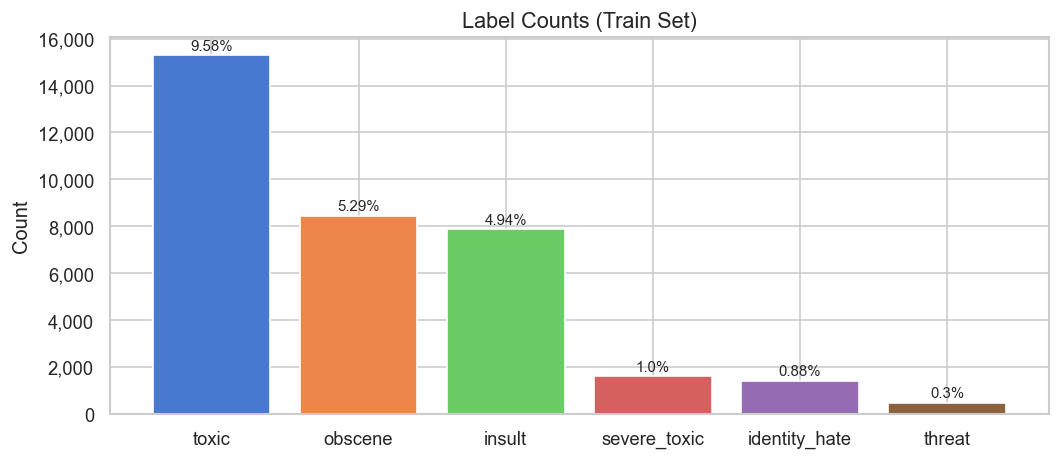

In [13]:
label_counts = train[LABELS].sum().sort_values(ascending=False)
label_pct    = (label_counts / len(train) * 100).round(2)

summary = pd.DataFrame({'count': label_counts, 'pct (%)': label_pct})
print(summary)
print(f'\nClean (no label): {(train[LABELS].sum(axis=1) == 0).sum():,} ({(train[LABELS].sum(axis=1) == 0).mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(label_counts.index, label_counts.values, color=sns.color_palette('muted', len(LABELS)))
for bar, pct in zip(bars, label_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f'{pct}%', ha='center', va='bottom', fontsize=9)
ax.set_title('Label Counts (Train Set)', fontsize=13)
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

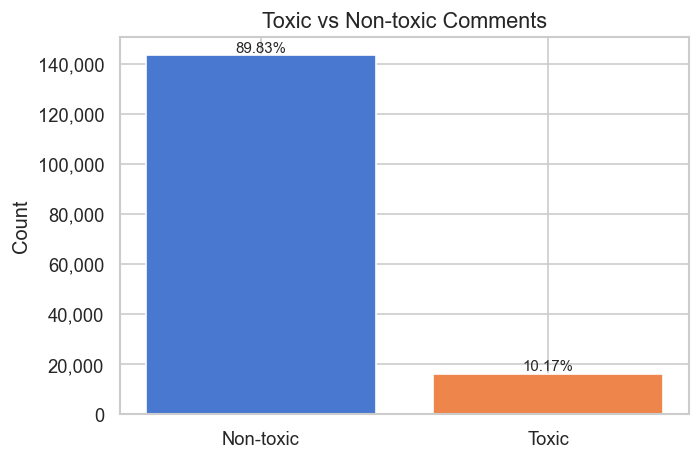

In [15]:
# Plot counts for toxic and non-toxic comments
train['is_toxic'] = (train[LABELS].sum(axis=1) > 0).astype(int)
tox_counts = train['is_toxic'].value_counts().sort_index()
tox_pct = (tox_counts / len(train) * 100).round(2)  
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Non-toxic', 'Toxic'], tox_counts.values, color=sns.color_palette('muted', 2))
for bar, pct in zip(bars, tox_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f'{pct}%', ha='center', va='bottom', fontsize=9)
ax.set_title('Toxic vs Non-toxic Comments', fontsize=13)
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()    


## 3. Label Co-occurrence

Are labels correlated? This tells us how to structure multi-label classification.

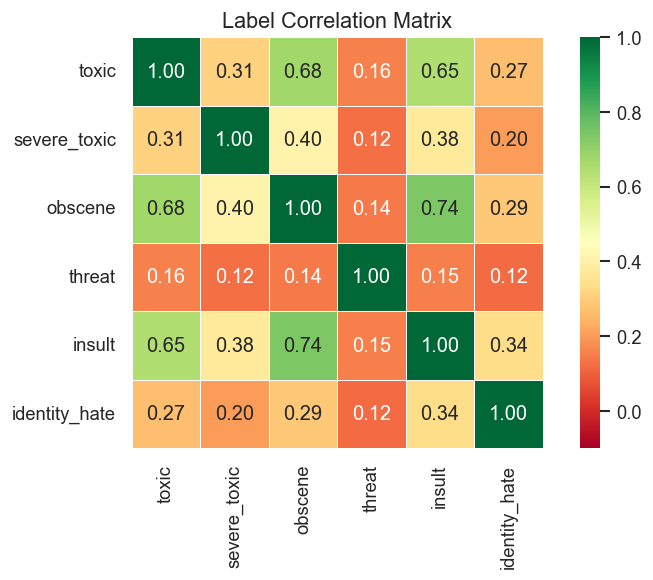


Co-occurrence (% of toxic rows that also have label):
  toxic & severe_toxic: 10.4%
  toxic & obscene: 51.8%
  toxic & threat: 2.9%
  toxic & insult: 48.0%
  toxic & identity_hate: 8.5%


In [4]:
corr = train[LABELS].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-0.1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Label Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# Co-occurrence counts
print('\nCo-occurrence (% of toxic rows that also have label):')
toxic_rows = train[train['toxic'] == 1]
for label in LABELS:
    if label == 'toxic': continue
    pct = toxic_rows[label].mean() * 100
    print(f'  toxic & {label}: {pct:.1f}%')

## 4. Multi-label Analysis

How many labels does a single comment typically carry?

Label count distribution:
  0 labels: 143,346 rows (89.83%)
  1 labels: 6,360 rows (3.99%)
  2 labels: 3,480 rows (2.18%)
  3 labels: 4,209 rows (2.64%)
  4 labels: 1,760 rows (1.10%)
  5 labels: 385 rows (0.24%)
  6 labels: 31 rows (0.02%)


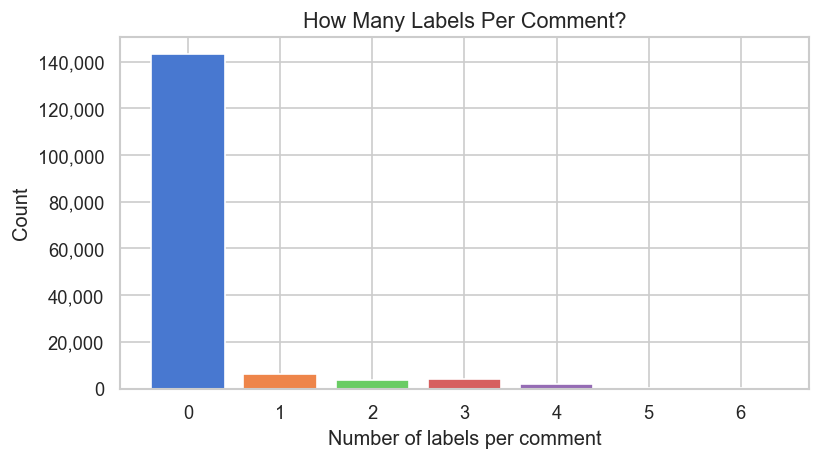

In [5]:
train['label_count'] = train[LABELS].sum(axis=1)
vc = train['label_count'].value_counts().sort_index()

print('Label count distribution:')
for k, v in vc.items():
    print(f'  {k} labels: {v:,} rows ({v/len(train)*100:.2f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(vc.index, vc.values, color=sns.color_palette('muted', len(vc)))
ax.set_xlabel('Number of labels per comment')
ax.set_ylabel('Count')
ax.set_title('How Many Labels Per Comment?', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 5. Text Length Analysis

Do toxic comments tend to be shorter or longer?

=== Character length ===
       text_len                                                
          count   mean    std  min    25%    50%    75%     max
toxic                                                          
0      144277.0  404.5  586.9  6.0  102.0  216.0  453.0  5000.0
1       15294.0  295.2  617.4  8.0   59.0  123.0  271.0  5000.0

=== Word count ===
      word_count                                            
           count  mean    std  min   25%   50%   75%     max
toxic                                                       
0       144277.0  69.0   98.3  1.0  18.0  38.0  78.0  1250.0
1        15294.0  51.3  106.5  2.0  11.0  22.0  48.0  1411.0


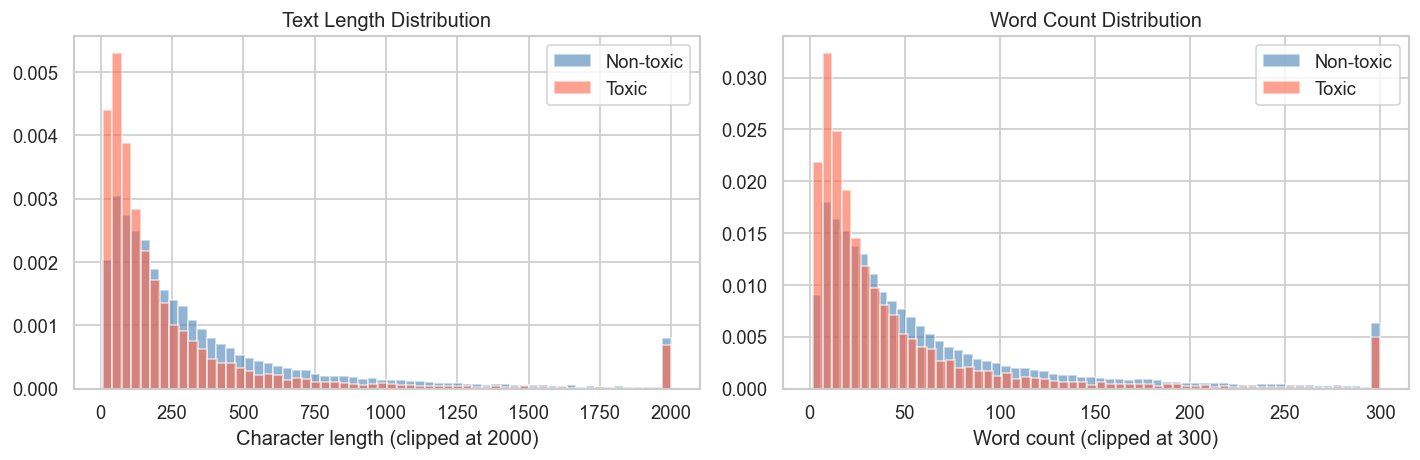

In [6]:
train['text_len'] = train['comment_text'].str.len()
train['word_count'] = train['comment_text'].str.split().str.len()

print('=== Character length ===')
print(train.groupby('toxic')[['text_len']].describe().round(1))
print('\n=== Word count ===')
print(train.groupby('toxic')[['word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for is_toxic, label, color in [(0, 'Non-toxic', 'steelblue'), (1, 'Toxic', 'tomato')]:
    subset = train[train['toxic'] == is_toxic]['text_len'].clip(upper=2000)
    axes[0].hist(subset, bins=60, alpha=0.6, label=label, color=color, density=True)

axes[0].set_xlabel('Character length (clipped at 2000)')
axes[0].set_title('Text Length Distribution')
axes[0].legend()

for is_toxic, label, color in [(0, 'Non-toxic', 'steelblue'), (1, 'Toxic', 'tomato')]:
    subset = train[train['toxic'] == is_toxic]['word_count'].clip(upper=300)
    axes[1].hist(subset, bins=60, alpha=0.6, label=label, color=color, density=True)

axes[1].set_xlabel('Word count (clipped at 300)')
axes[1].set_title('Word Count Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Top Tokens Per Label

What words are most associated with each label (vs. non-toxic)?

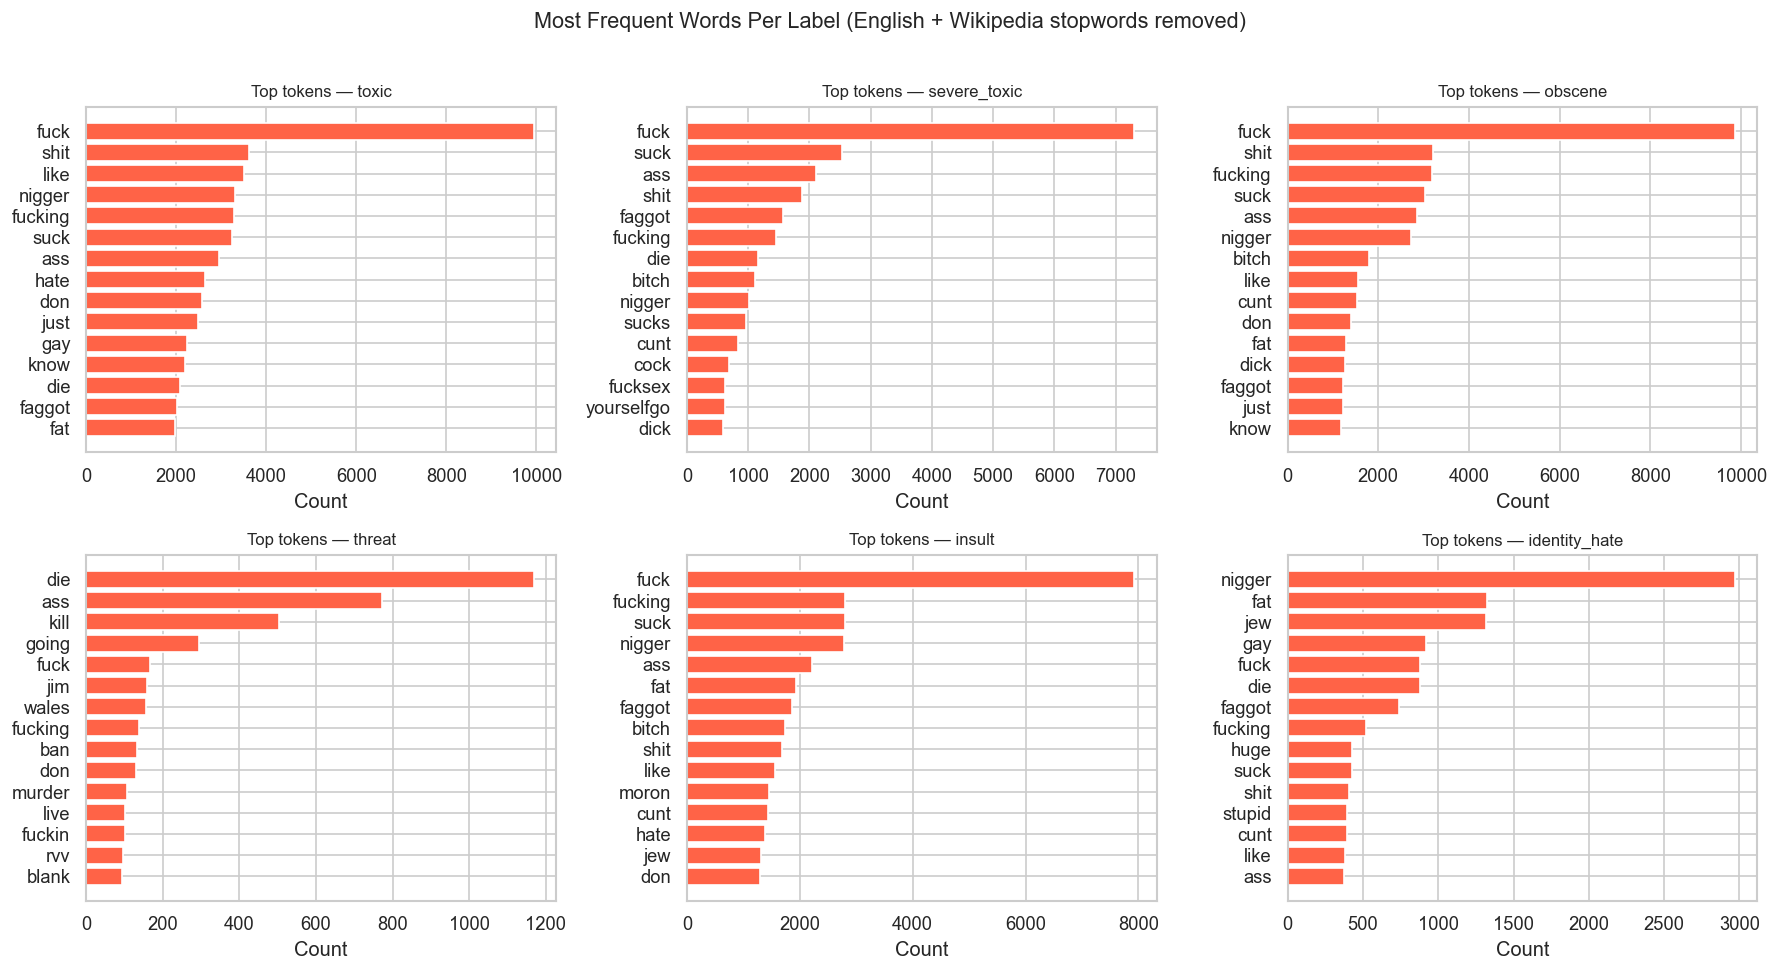

In [7]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Wikipedia platform terms — these are dataset artifacts, not toxicity signals.
# Removing them so they don't dominate the top-token charts.
DOMAIN_STOPWORDS = {
    'wikipedia', 'wiki', 'article', 'articles', 'talk', 'page', 'pages',
    'edit', 'edits', 'edited', 'editing', 'editor', 'editors',
    'user', 'users', 'username', 'block', 'blocked', 'blocking',
    'template', 'unsigned', 'utc', 'http', 'www', 'com',
    'archive', 'revision', 'section', 'category', 'source',
    'deleted', 'deletion', 'admin', 'administrator'
}

ALL_STOPWORDS = list(ENGLISH_STOP_WORDS.union(DOMAIN_STOPWORDS))

def top_tokens(texts, n=20):
    vec = CountVectorizer(
        stop_words=ALL_STOPWORDS,
        max_features=50_000,
        token_pattern=r'\b[a-z]{3,}\b'
    )
    X = vec.fit_transform(texts.str.lower())
    counts = np.asarray(X.sum(axis=0)).ravel()
    vocab = vec.get_feature_names_out()
    top_idx = counts.argsort()[::-1][:n]
    return [(vocab[i], counts[i]) for i in top_idx]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, label in zip(axes, LABELS):
    subset = train[train[label] == 1]['comment_text']
    tokens = top_tokens(subset, n=15)
    words, counts = zip(*tokens)
    ax.barh(words[::-1], counts[::-1], color='tomato')
    ax.set_title(f'Top tokens — {label}', fontsize=10)
    ax.set_xlabel('Count')

plt.suptitle('Most Frequent Words Per Label (English + Wikipedia stopwords removed)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Test Set — Filtering -1 Labels

The test labels contain `-1` for rows that were withheld from scoring in the original competition.  
**These must be excluded** before computing any evaluation metrics.

In [8]:
print('Test labels value counts (toxic column):')
print(test_labels['toxic'].value_counts())

evaluable = test_labels[test_labels['toxic'] != -1]
print(f'\nEvaluable test rows: {len(evaluable):,} / {len(test_labels):,} ({len(evaluable)/len(test_labels)*100:.1f}%)')

# Merge with text so we have a ready-to-use eval set
eval_df = evaluable.merge(test[['id', 'comment_text']], on='id')
print(f'Eval set shape: {eval_df.shape}')
print('\nLabel distribution in eval set:')
print(eval_df[LABELS].sum())
eval_df.head(3)

Test labels value counts (toxic column):
toxic
-1    89186
 0    57888
 1     6090
Name: count, dtype: int64

Evaluable test rows: 63,978 / 153,164 (41.8%)
Eval set shape: (63978, 8)

Label distribution in eval set:
toxic            6090
severe_toxic      367
obscene          3691
threat            211
insult           3427
identity_hate     712
dtype: int64


,id,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_text
0,0001ea8717f6de06,0,0,0,0,0,0,Thank you for understanding. I think very high...
1,000247e83dcc1211,0,0,0,0,0,0,:Dear god this site is horrible.
2,0002f87b16116a7f,0,0,0,0,0,0,"""::: Somebody will invariably try to add Relig..."


## 9. Slang Proportion Analysis

**Goal**: Estimate how much internet slang appears in these Wikipedia comments to decide whether a slang-decoder preprocessing step would add signal.

We reuse the slang lexicon already built in `preprocessing.py`, which loads [`MLBtrio/genz-slang-dataset`](https://huggingface.co/datasets/MLBtrio/genz-slang-dataset) from HuggingFace.

In [9]:
import sys
sys.path.insert(0, '../models')

from preprocessing import _get_slang_resources

# Load the same slang map used by the preprocessing pipeline
token_map, _ = _get_slang_resources()
print(f"Slang lexicon size: {len(token_map):,} single-token terms")

# Compute per-comment: slang hit count, total tokens, slang ratio
def _slang_stats(text):
    tokens = re.sub(r'[^\w\s]', ' ', str(text).lower()).split()
    if not tokens:
        return 0, 0
    hits = sum(1 for t in tokens if t in token_map)
    return hits, len(tokens)

print("Computing slang ratios…")
_stats = train['comment_text'].apply(_slang_stats)
train['slang_count'] = _stats.apply(lambda x: x[0])
train['word_count2'] = _stats.apply(lambda x: x[1])
train['slang_ratio'] = train['slang_count'] / train['word_count2'].replace(0, float('nan'))
train['has_slang']   = train['slang_count'] > 0

print(f"\nOverall: {train['has_slang'].mean()*100:.1f}% of comments contain ≥1 slang term")
print(f"Mean slang ratio: {train['slang_ratio'].mean()*100:.2f}%")

[preprocessing] Loading slang dataset from HuggingFace...


[preprocessing] Loaded 1491 single-token and 40 multi-word slang entries.
Slang lexicon size: 1,491 single-token terms
Computing slang ratios…

Overall: 61.5% of comments contain ≥1 slang term
Mean slang ratio: 3.23%


               pct_with_slang (%)  mean_slang_ratio (%)
toxic                   56.570000               4.21000
severe_toxic            45.080000               4.45000
obscene                 54.980000               4.47000
threat                  54.600000               3.85000
insult                  54.160000               4.29000
identity_hate           50.040000               4.09000
clean                   62.034518               3.11787


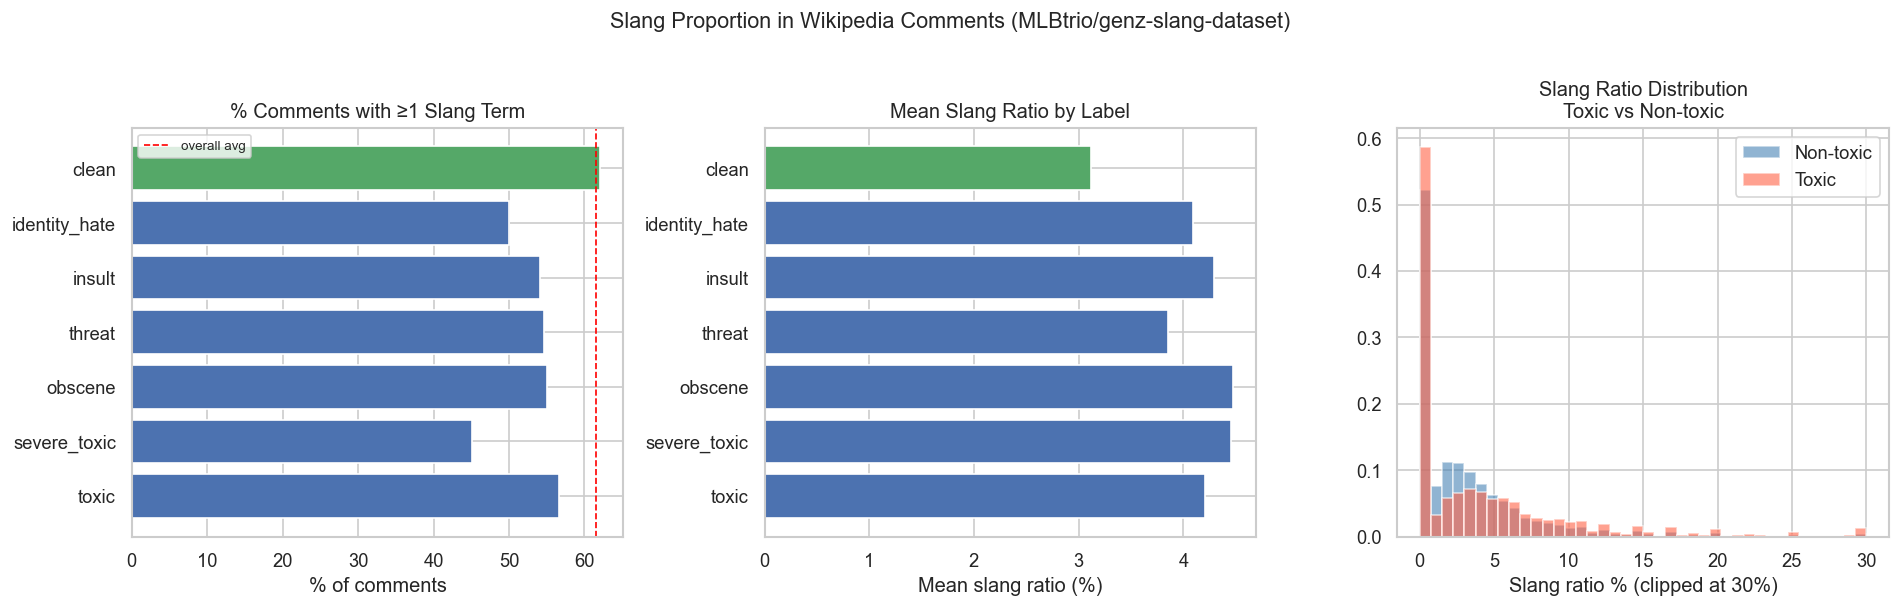

In [10]:
# Per-label slang prevalence table
label_slang = pd.DataFrame({
    label: {
        'pct_with_slang (%)': train[train[label] == 1]['has_slang'].mean() * 100,
        'mean_slang_ratio (%)': train[train[label] == 1]['slang_ratio'].mean() * 100,
    }
    for label in LABELS
}).T.round(2)
label_slang.loc['clean'] = [
    train[train[LABELS].sum(axis=1) == 0]['has_slang'].mean() * 100,
    train[train[LABELS].sum(axis=1) == 0]['slang_ratio'].mean() * 100,
]
print(label_slang.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot A — % comments with ≥1 slang per label
ax = axes[0]
colors = ['#4c72b0'] * len(LABELS) + ['#55a868']
ax.barh(label_slang.index, label_slang['pct_with_slang (%)'], color=colors)
ax.axvline(train['has_slang'].mean() * 100, color='red', ls='--', lw=1, label='overall avg')
ax.set_xlabel('% of comments')
ax.set_title('% Comments with ≥1 Slang Term')
ax.legend(fontsize=8)

# Plot B — mean slang ratio per label
ax = axes[1]
ax.barh(label_slang.index, label_slang['mean_slang_ratio (%)'], color=colors)
ax.set_xlabel('Mean slang ratio (%)')
ax.set_title('Mean Slang Ratio by Label')

# Plot C — slang ratio distribution, toxic vs non-toxic
ax = axes[2]
for is_toxic, label, color in [(0, 'Non-toxic', 'steelblue'), (1, 'Toxic', 'tomato')]:
    ratios = train[train['toxic'] == is_toxic]['slang_ratio'].clip(upper=0.3).dropna() * 100
    ax.hist(ratios, bins=40, alpha=0.6, label=label, color=color, density=True)
ax.set_xlabel('Slang ratio % (clipped at 30%)')
ax.set_title('Slang Ratio Distribution\nToxic vs Non-toxic')
ax.legend()

plt.suptitle('Slang Proportion in Wikipedia Comments (MLBtrio/genz-slang-dataset)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

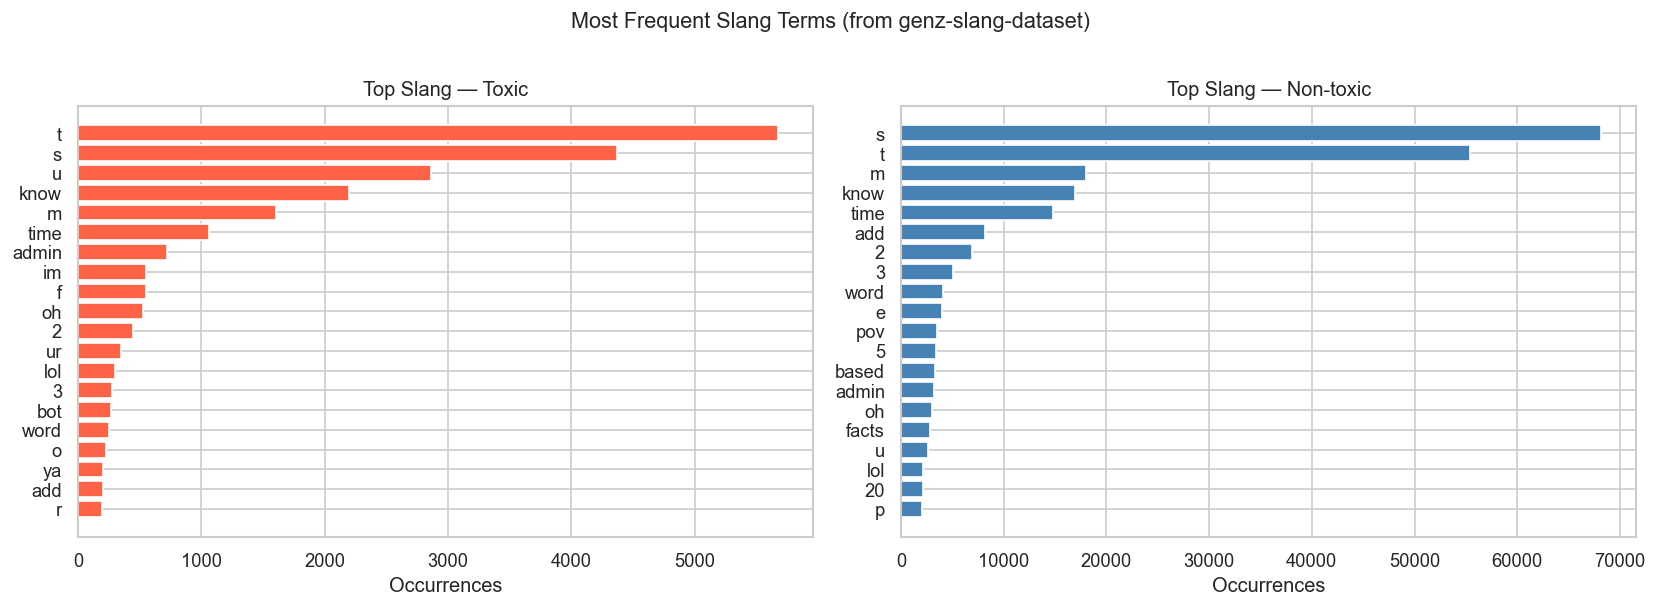

Toxic comments with ≥1 slang:     56.6%
Non-toxic comments with ≥1 slang: 62.1%
Lift (toxic / non-toxic):          0.91x
→ Lift is low — slang decoding may not improve model signal.


In [11]:
# Top slang terms in toxic vs non-toxic comments
def top_slang(texts, n=20):
    counts = Counter()
    for text in texts:
        tokens = re.sub(r'[^\w\s]', ' ', str(text).lower()).split()
        counts.update(t for t in tokens if t in token_map)
    return counts.most_common(n)

toxic_top    = top_slang(train[train['toxic'] == 1]['comment_text'])
nontoxic_top = top_slang(train[train['toxic'] == 0]['comment_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, items, title, color in [
    (axes[0], toxic_top,    'Top Slang — Toxic',     'tomato'),
    (axes[1], nontoxic_top, 'Top Slang — Non-toxic', 'steelblue'),
]:
    words, counts = zip(*items)
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_xlabel('Occurrences')
    ax.set_title(title)

plt.suptitle('Most Frequent Slang Terms (from genz-slang-dataset)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Decision helper
toxic_pct    = train[train['toxic'] == 1]['has_slang'].mean() * 100
nontoxic_pct = train[train['toxic'] == 0]['has_slang'].mean() * 100
lift = toxic_pct / nontoxic_pct if nontoxic_pct > 0 else float('inf')

print("=" * 55)
print(f"Toxic comments with ≥1 slang:     {toxic_pct:.1f}%")
print(f"Non-toxic comments with ≥1 slang: {nontoxic_pct:.1f}%")
print(f"Lift (toxic / non-toxic):          {lift:.2f}x")
print("=" * 55)
if lift > 1.5:
    print("→ Slang is enriched in toxic comments — slang decoding")
    print("  (preprocessing.py clean_text(slang=True)) is worth using.")
else:
    print("→ Lift is low — slang decoding may not improve model signal.")

## 8. Key Takeaways

| Finding | Implication |
|---|---|
| ~10% of train rows have any toxic label | Heavy class imbalance — use `class_weight='balanced'` or oversample |
| `obscene` (51.8%) and `insult` (48.0%) most often co-occur with `toxic`; `severe_toxic` is only 10.4% | Labels are not equally coupled — don't assume severity tracks toxicity |
| `threat` is extremely rare (0.3%) | Expect low recall on threat; may need separate handling or oversampling |
| Toxic comments are shorter on average (123 median words vs 216) | Model may pick up on this as a weak signal |
| 63k / 153k test rows have real labels | Always filter `label == -1` rows before computing any eval metrics |
| Multi-label: use `BCEWithLogitsLoss` for BERT | Not softmax/cross-entropy — each label is independent |
| Top tokens dominated by Wikipedia platform terms | Strip domain stopwords (`wikipedia`, `edit`, `talk`, etc.) before training |